<a href="https://colab.research.google.com/github/AriQuiros/Proyecto_Analisis_de_Datos/blob/main/Pablo_proyecto3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

**Importación de librerías**


* **pandas** se utiliza para leer y manipular el archivo CSV.
* **numpy** se usa para operaciones numéricas y manejo de valores especiales.
* **matplotlib** y **seaborn** permiten crear gráficos estadísticos.
* **plotly.express** se utiliza para generar un mapa mundial interactivo

In [16]:
file_path = "fusion_CME_UNICEF_1.0_all.csv"

df = pd.read_csv(file_path, low_memory=False)

print("Dimensiones del dataset:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())


Dimensiones del dataset: (790460, 14)

Columnas:
['DATAFLOW', 'REF_AREA:Geographic area', 'INDICATOR:Indicator', 'SEX:Sex', 'WEALTH_QUINTILE:Wealth Quintile', 'TIME_PERIOD:Time period', 'OBS_VALUE:Observation Value', 'DATA_SOURCE:Data Source', 'COUNTRY_NOTES:Country notes', 'UNIT_MEASURE:Unit of measure', 'REF_PERIOD:Reference Period', 'LOWER_BOUND:Lower Bound', 'UPPER_BOUND:Upper Bound', 'OBS_STATUS:Observation Status']


Algunas columnas del dataset vienen en formato código:descripción, por ejemplo WORLD:World o M:Male.

En esta sección se separan esos valores en dos columnas diferentes: una para el código y otra para el nombre, lo que facilita el filtrado y la interpretación de los datos.

astype(str) convierte los valores a texto para evitar errores.

split(":") divide el contenido usando : como separador.

str[0] toma la primera parte y str[1] toma la segunda.

strip() elimina espacios en blanco al inicio o al final.

In [17]:
df = df.rename(columns={
    "REF_AREA:Geographic area": "area",
    "INDICATOR:Indicator": "indicator",
    "SEX:Sex": "sex",
    "WEALTH_QUINTILE:Wealth Quintile": "wealth_quintile",
    "TIME_PERIOD:Time period": "year",
    "OBS_VALUE:Observation Value": "value",
    "DATA_SOURCE:Data Source": "data_source",
    "COUNTRY_NOTES:Country notes": "country_notes",
    "UNIT_MEASURE:Unit of measure": "unit_measure",
    "REF_PERIOD:Reference Period": "ref_period",
    "LOWER_BOUND:Lower Bound": "lower_bound",
    "UPPER_BOUND:Upper Bound": "upper_bound",
    "OBS_STATUS:Observation Status": "obs_status"
})

df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["value"] = pd.to_numeric(df["value"], errors="coerce")
df["lower_bound"] = pd.to_numeric(df["lower_bound"], errors="coerce")
df["upper_bound"] = pd.to_numeric(df["upper_bound"], errors="coerce")

df["area_code"] = df["area"].astype(str).str.split(":").str[0]
df["area_name"] = df["area"].astype(str).str.split(":", n=1).str[1].str.strip()

df["indicator_code"] = df["indicator"].astype(str).str.split(":").str[0]
df["indicator_name"] = df["indicator"].astype(str).str.split(":", n=1).str[1].str.strip()

df["sex_code"] = df["sex"].astype(str).str.split(":").str[0]
df["sex_name"] = df["sex"].astype(str).str.split(":", n=1).str[1].str.strip()

df["wealth_code"] = df["wealth_quintile"].astype(str).str.split(":").str[0]
df["wealth_name"] = df["wealth_quintile"].astype(str).str.split(":", n=1).str[1].str.strip()


Se filtran los datos para trabajar únicamente con el indicador de mortalidad infantil (CME_MRY0) y se eliminan registros sin valores numéricos.
Luego, se obtiene el rango de años disponible en el dataset y se identifica automáticamente el último año.

Posteriormente, se filtran los datos totales (sexo total y quintil total) para tener una visión global.

Finalmente, se extrae la serie correspondiente al mundo (WORLD), ordenada por año, y se muestra una vista inicial con los valores principales (año, valor y límites de incertidumbre).

In [18]:
infant_df = df[
    (df["indicator_code"] == "CME_MRY0") &
    (df["value"].notna())
].copy()

print("\nRango de años disponible en mortalidad infantil:")
print(int(infant_df["year"].min()), "a", int(infant_df["year"].max()))

infant_total = infant_df[
    (infant_df["sex_code"] == "_T") &
    (infant_df["wealth_code"] == "_T")
].copy()

world_df = infant_total[infant_total["area_code"] == "WORLD"].sort_values("year")

print("\nVista rápida de la serie mundial:")
display(world_df[["year", "value", "lower_bound", "upper_bound"]].head())



Rango de años disponible en mortalidad infantil:
1932 a 2023

Vista rápida de la serie mundial:


,year,value,lower_bound,upper_bound
767813,1990,63.963396,63.036251,65.044951
767814,1991,64.152447,63.300789,65.138029
767815,1992,63.441181,62.634110,64.390321
767816,1993,62.233811,61.490070,63.148376
767817,1994,61.444942,60.717807,62.324299


Se genera un gráfico de línea que muestra la tendencia de la mortalidad infantil a nivel mundial a lo largo del tiempo.

Se utiliza el año en el eje horizontal y la tasa de mortalidad en el eje vertical, permitiendo visualizar la evolución del indicador y detectar si existe una disminución o aumento en el período analizado.

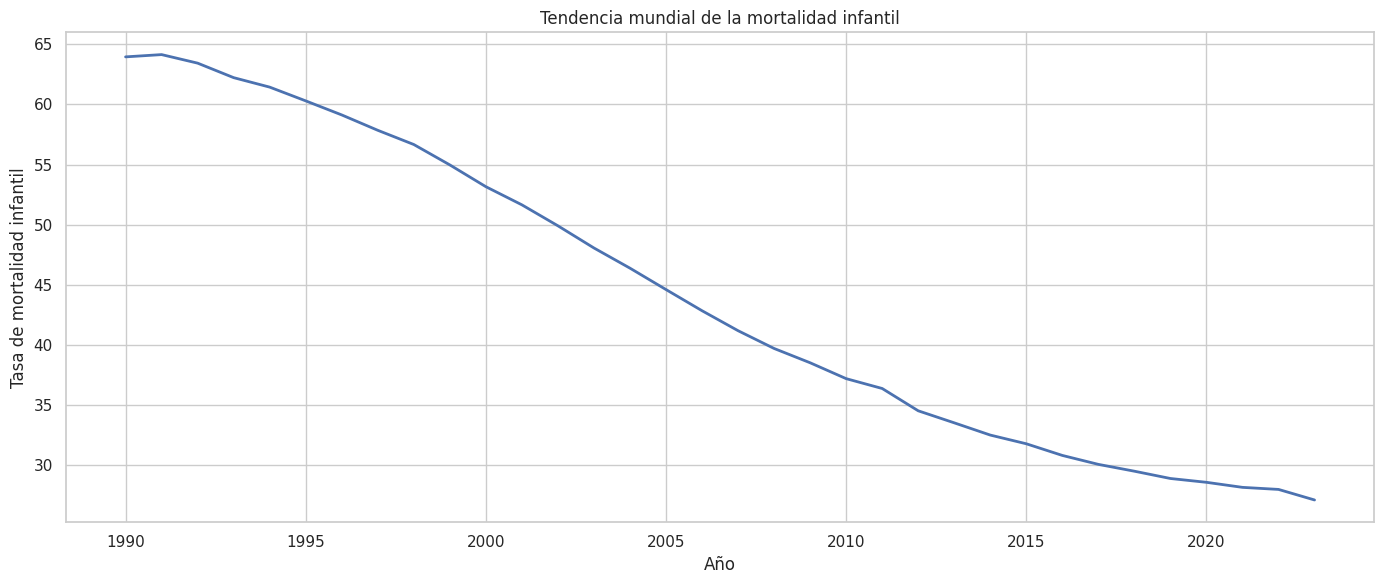

In [19]:
plt.figure(figsize=(14, 6))
plt.plot(world_df["year"], world_df["value"], linewidth=2)
plt.title("Tendencia mundial de la mortalidad infantil")
plt.xlabel("Año")
plt.ylabel("Tasa de mortalidad infantil")
plt.tight_layout()
plt.show()

Se filtran los datos para analizar la mortalidad infantil a nivel mundial según sexo (total, masculino y femenino), considerando únicamente los valores globales.

Luego, se genera un gráfico de líneas donde cada línea representa un grupo, permitiendo comparar la evolución de la mortalidad infantil entre hombres, mujeres y el total a lo largo del tiempo.

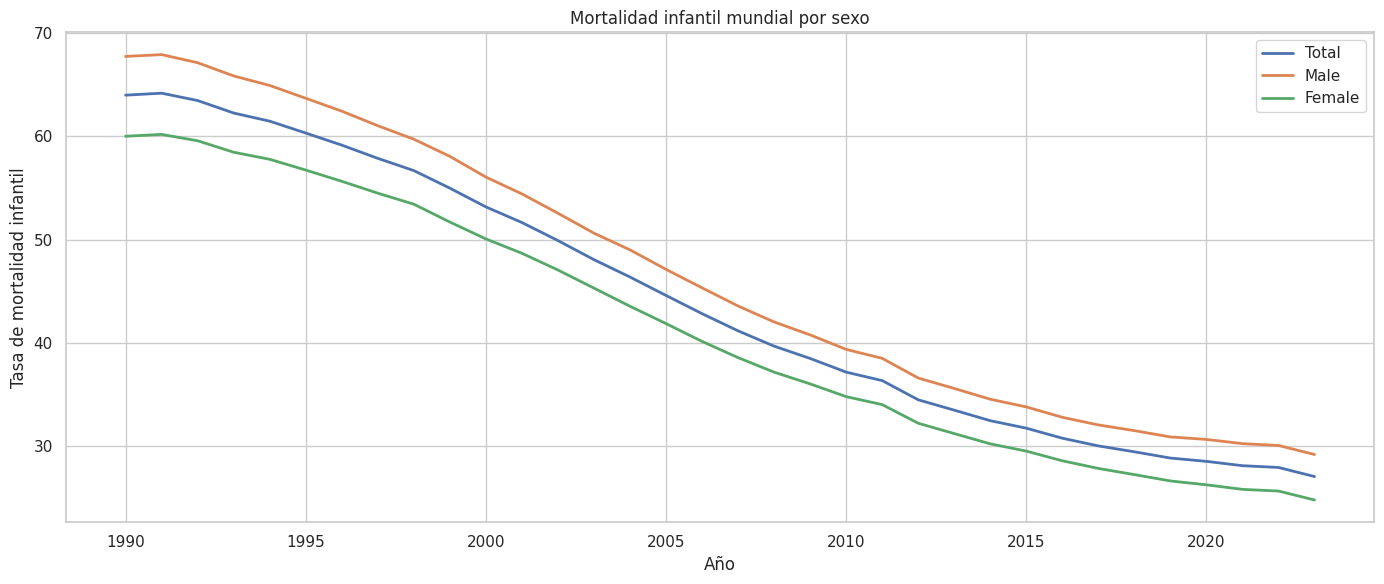

In [26]:
world_sex = infant_df[
    (infant_df["area_code"] == "WORLD") &
    (infant_df["wealth_code"] == "_T") &
    (infant_df["sex_code"].isin(["M", "F", "_T"]))
].copy()

plt.figure(figsize=(14, 6))
for sex_code, label in [("_T", "Total"), ("M", "Male"), ("F", "Female")]:
    temp = world_sex[world_sex["sex_code"] == sex_code].sort_values("year")
    if not temp.empty:
        plt.plot(temp["year"], temp["value"], label=label, linewidth=2)

plt.title("Mortalidad infantil mundial por sexo")
plt.xlabel("Año")
plt.ylabel("Tasa de mortalidad infantil")
plt.legend()
plt.tight_layout()
plt.show()

Se filtran los datos correspondientes al último año disponible para obtener únicamente países, excluyendo regiones (códigos WB_) y el total mundial.
Luego, se seleccionan los 10 países con mayor tasa de mortalidad infantil y se ordenan de forma descendente.

Permitiendo identificar dónde se concentran los niveles más altos de mortalidad infantil en el período más reciente.

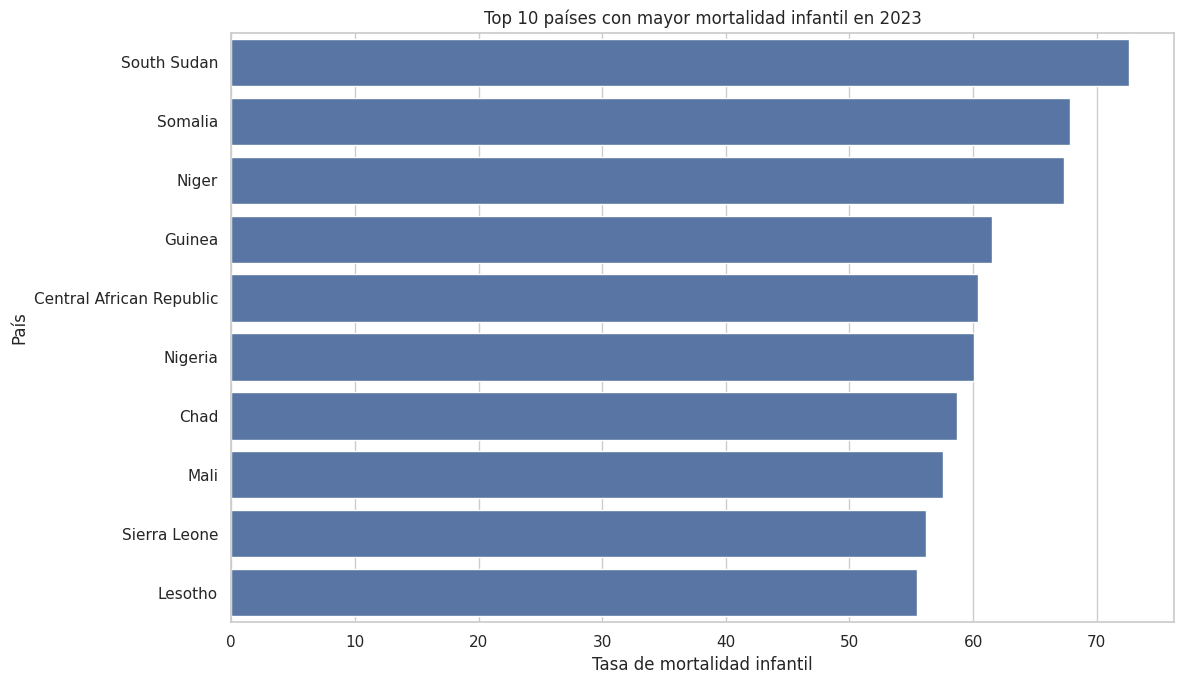

,area_name,year,value
537013,South Sudan,2023,72.616073
530991,Somalia,2023,67.839535
421048,Niger,2023,67.361474
219063,Guinea,2023,61.548732
95412,Central African Republic,2023,60.413259
424408,Nigeria,2023,60.097514
569686,Chad,2023,58.687529
381674,Mali,2023,57.553430
521527,Sierra Leone,2023,56.168081
343357,Lesotho,2023,55.422959


In [27]:
latest_year = int(infant_total["year"].max())

country_latest = infant_total[
    (infant_total["year"] == latest_year) &
    (~infant_total["area_code"].str.startswith("WB_", na=False)) &
    (infant_total["area_code"] != "WORLD")
].copy()

top10_latest = country_latest.sort_values("value", ascending=False).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(data=top10_latest, x="value", y="area_name")
plt.title(f"Top 10 países con mayor mortalidad infantil en {latest_year}")
plt.xlabel("Tasa de mortalidad infantil")
plt.ylabel("País")
plt.tight_layout()
plt.show()

display(top10_latest[["area_name", "year", "value"]])

Se define un año base para comparar la evolución de la mortalidad infantil, utilizando 1990 si está disponible en el dataset; de lo contrario, se toma el primer año registrado.
Luego, se extraen los valores de cada país en el año base y en el último año disponible, excluyendo regiones y el total mundial.

Después, ambos conjuntos de datos se unen por código y nombre de país para calcular la reducción absoluta y la reducción porcentual de la mortalidad infantil.
Finalmente, se seleccionan los 10 países con mayor mejora relativa, se representan en un gráfico de barras y se muestran sus valores en una tabla para comparar el avance logrado en el período analizado.

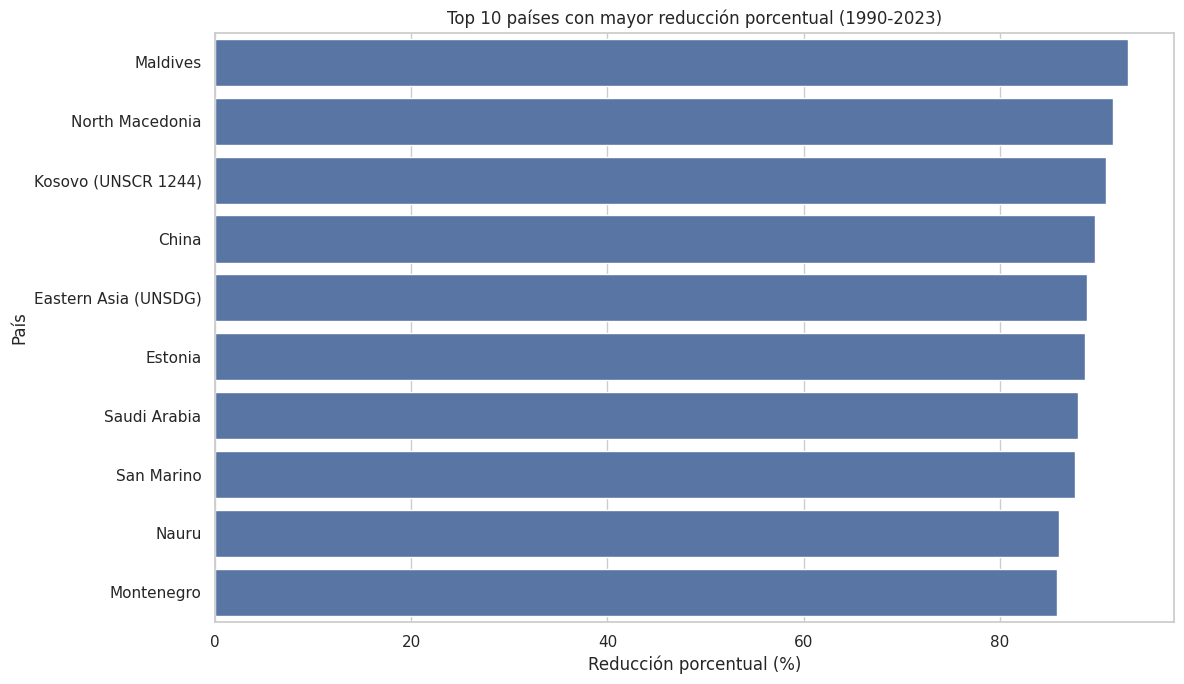

,area_name,value_base,value_latest,percent_reduction
111,Maldives,71.830010,4.979370,93.067842
114,North Macedonia,33.341692,2.848183,91.457593
239,Kosovo (UNSCR 1244),90.502532,8.339234,90.785635
33,China,43.263199,4.451313,89.711087
207,Eastern Asia (UNSDG),40.981542,4.585500,88.810816
56,Estonia,14.032056,1.597962,88.612063
152,Saudi Arabia,40.532572,4.882460,87.954232
159,San Marino,11.082864,1.366837,87.667115
134,Nauru,59.154232,8.291681,85.982946
118,Montenegro,14.815700,2.107986,85.771944


In [24]:
base_year = 1990 if 1990 in infant_total["year"].unique() else int(infant_total["year"].min())

country_base = infant_total[
    (infant_total["year"] == base_year) &
    (~infant_total["area_code"].str.startswith("WB_", na=False)) &
    (infant_total["area_code"] != "WORLD")
][["area_code", "area_name", "value"]].rename(columns={"value": "value_base"})

country_end = infant_total[
    (infant_total["year"] == latest_year) &
    (~infant_total["area_code"].str.startswith("WB_", na=False)) &
    (infant_total["area_code"] != "WORLD")
][["area_code", "area_name", "value"]].rename(columns={"value": "value_latest"})

improvement = pd.merge(country_base, country_end, on=["area_code", "area_name"], how="inner")
improvement["absolute_reduction"] = improvement["value_base"] - improvement["value_latest"]
improvement["percent_reduction"] = np.where(
    improvement["value_base"] > 0,
    (improvement["absolute_reduction"] / improvement["value_base"]) * 100,
    np.nan
)

top10_improvement = improvement.sort_values("percent_reduction", ascending=False).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(data=top10_improvement, x="percent_reduction", y="area_name")
plt.title(f"Top 10 países con mayor reducción porcentual ({base_year}-{latest_year})")
plt.xlabel("Reducción porcentual (%)")
plt.ylabel("País")
plt.tight_layout()
plt.show()

display(top10_improvement[["area_name", "value_base", "value_latest", "percent_reduction"]])


Se selecciona un conjunto de países específicos para analizar su comportamiento a lo largo del tiempo.
Luego, se filtran los datos correspondientes a esos países y se reorganizan en una tabla tipo matriz, donde las filas representan países y las columnas los años.

A partir de esta estructura, se genera un heatmap que utiliza colores para representar la intensidad de la mortalidad infantil, permitiendo identificar patrones, tendencias y comparaciones entre países de forma visual.


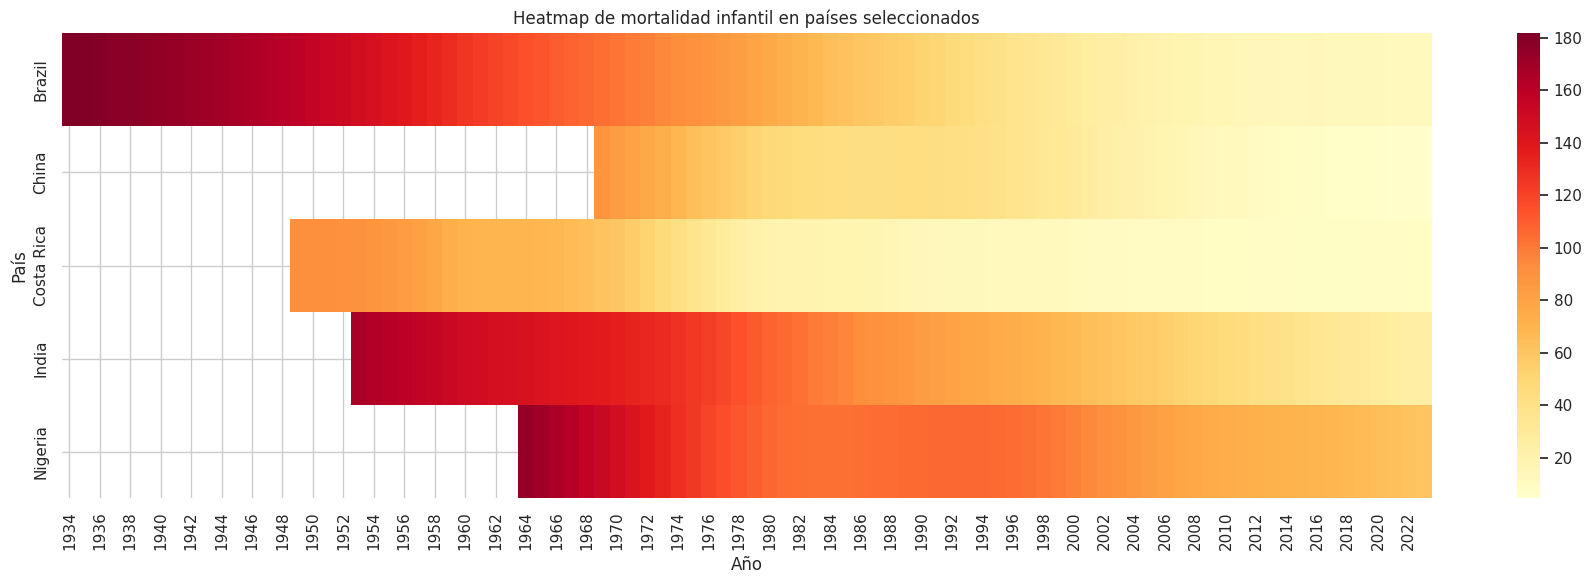

In [28]:
selected_countries = [
    "Costa Rica",
    "United States of America",
    "Brazil",
    "India",
    "Nigeria",
    "China"
]

heat_df = infant_total[
    infant_total["area_name"].isin(selected_countries)
].copy()

pivot_heat = heat_df.pivot_table(
    index="area_name",
    columns="year",
    values="value",
    aggfunc="mean"
)

plt.figure(figsize=(18, 6))
sns.heatmap(pivot_heat, cmap="YlOrRd")
plt.title("Heatmap de mortalidad infantil en países seleccionados")
plt.xlabel("Año")
plt.ylabel("País")
plt.tight_layout()
plt.show()

Se filtran los datos correspondientes a los grupos de ingreso del Banco Mundial (alto, medio alto, medio bajo y bajo).

Luego, se genera un gráfico de líneas donde cada línea representa un grupo de ingreso, permitiendo comparar la evolución de la mortalidad infantil según el nivel económico de los países a lo largo del tiempo.

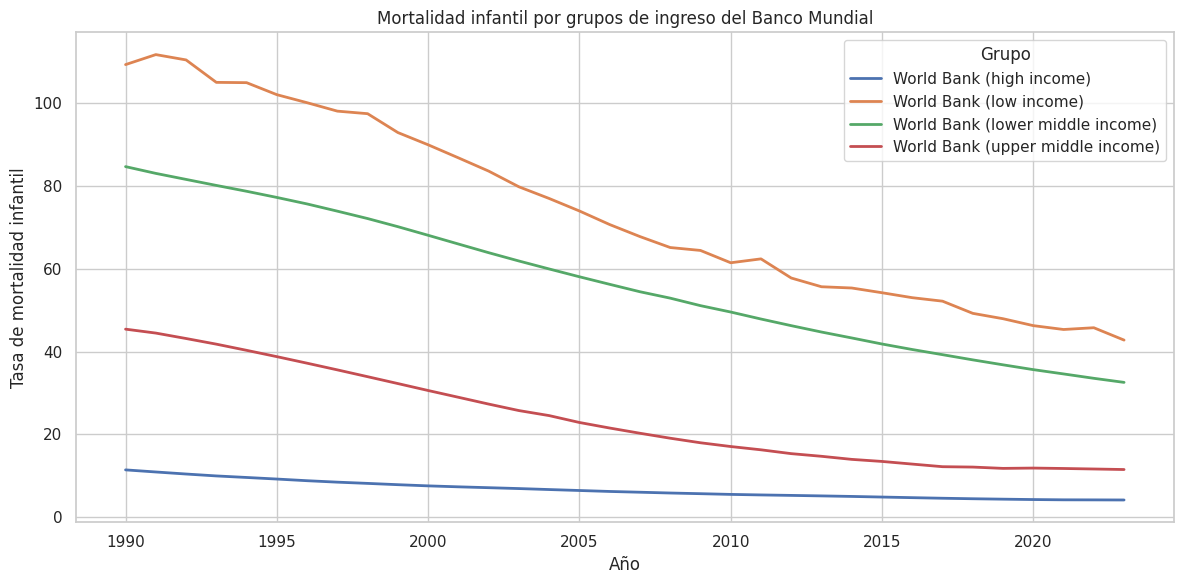

In [29]:
income_codes = ["WB_HI", "WB_UMI", "WB_LMI", "WB_LI"]
income_df = infant_total[infant_total["area_code"].isin(income_codes)].copy()

plt.figure(figsize=(12, 6))
sns.lineplot(data=income_df, x="year", y="value", hue="area_name", linewidth=2)
plt.title("Mortalidad infantil por grupos de ingreso del Banco Mundial")
plt.xlabel("Año")
plt.ylabel("Tasa de mortalidad infantil")
plt.legend(title="Grupo")
plt.tight_layout()
plt.show()

Se crea un mapa mundial interactivo utilizando los datos del último año disponible.
Cada país se colorea según su tasa de mortalidad infantil, lo que permite visualizar de forma geográfica dónde se concentran los niveles más altos y más bajos del indicador.
Además, al pasar el cursor sobre cada país, se muestra su nombre y valor correspondiente.

In [30]:
map_df = country_latest.copy()

fig = px.choropleth(
    map_df,
    locations="area_name",
    locationmode="country names",
    color="value",
    hover_name="area_name",
    color_continuous_scale="Reds",
    title=f"Mapa mundial de mortalidad infantil ({latest_year})"
)
fig.show()


Se calculan indicadores generales de la serie mundial, como el año inicial y final, así como los valores de mortalidad infantil en esos años.
Luego, se determina la reducción porcentual del indicador a lo largo del período analizado.

Finalmente, se imprime un resumen automático que describe la evolución de la mortalidad infantil mundial y el nivel de mejora alcanzado.

In [31]:
initial_year = int(world_df["year"].min())
final_year = int(world_df["year"].max())
initial_value = float(world_df.iloc[0]["value"])
final_value = float(world_df.iloc[-1]["value"])
reduction_pct = ((initial_value - final_value) / initial_value) * 100 if initial_value > 0 else np.nan

print("Resumen automático:")
print(f"- La serie mundial disponible va de {initial_year} a {final_year}.")
print(f"- La mortalidad infantil mundial pasó de {initial_value:.2f} a {final_value:.2f}.")
print(f"- La reducción estimada en el periodo fue de {reduction_pct:.2f}%.")


Resumen automático:
- La serie mundial disponible va de 1990 a 2023.
- La mortalidad infantil mundial pasó de 63.96 a 27.08.
- La reducción estimada en el periodo fue de 57.67%.


## Funciones Auxiliares para Análisis de Mortalidad Infantil

A continuación, se definen cuatro funciones que facilitan la consulta y comparación de los datos de mortalidad infantil.

### 1. `Obtener mortalidad por país y año`

Esta función permite obtener la tasa de mortalidad infantil para un país y un año específicos. Es útil para consultas puntuales sobre un país en un momento dado.

In [47]:
def get_mortality_by_country_and_year(country_name, year):

    data = infant_total[
        (infant_total['area_name'] == country_name) &
        (infant_total['year'] == year)
    ]
    if not data.empty:
        display(data[['area_name', 'year', 'value', 'lower_bound', 'upper_bound']])
        return data.iloc[0]
    else:
        print(f"No se encontraron datos para {country_name} en {year}.")
        return None

print("Ejemplo de uso de get_mortality_by_country_and_year para Costa Rica en el año 2000:")
get_mortality_by_country_and_year("Costa Rica", 2000)

Ejemplo de uso de get_mortality_by_country_and_year para Costa Rica en el año 2000:


,area_name,year,value,lower_bound,upper_bound
139594,Costa Rica,2000,11.222113,10.965444,11.48358


,139594
DATAFLOW,UNICEF:CME(1.0): Child Mortality
area,CRI: Costa Rica
indicator,CME_MRY0: Infant mortality rate
sex,_T: Total
wealth_quintile,_T: Total
year,2000
value,11.222113
data_source,UN_IGME
country_notes,NaN
unit_measure,"D_PER_1000_B: Deaths per 1,000 live births"


### 2. `Comparamos 2 paises (compare_two_countries_simple)`

Esta función compara la tendencia de mortalidad infantil entre dos países en un rango de años, mostrando un gráfico de línea. Ideal para visualizaciones rápidas de comparaciones binarias.

Ejemplo de uso de compare_two_countries_simple, comparamos Mexico vs Brazil:


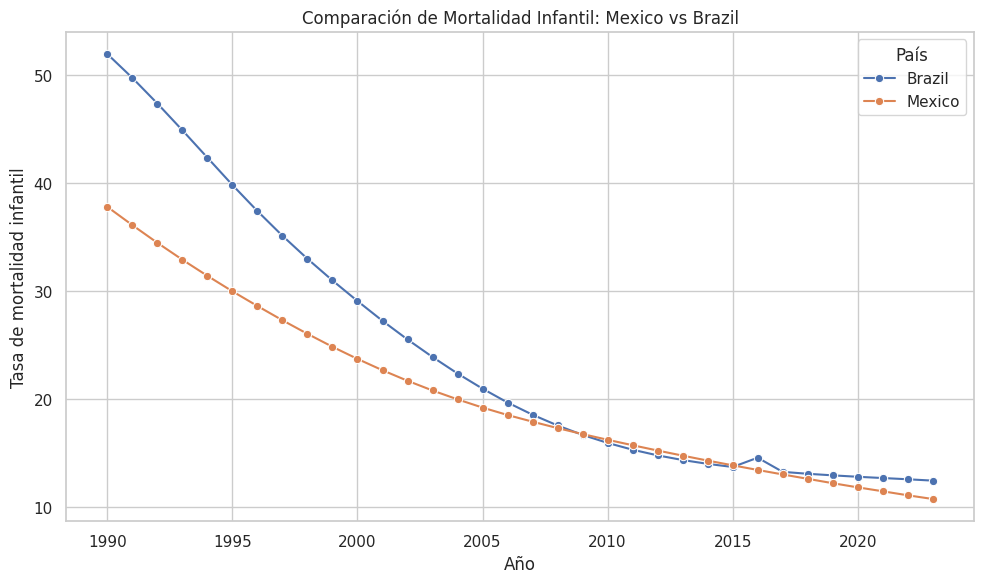

In [54]:
def compare_two_countries_simple(country1, country2, start_year, end_year):

    countries = [country1, country2]
    comparison_data = infant_total[
        (infant_total['area_name'].isin(countries)) &
        (infant_total['year'] >= start_year) &
        (infant_total['year'] <= end_year)
    ].sort_values('year')

    if not comparison_data.empty:
        plt.figure(figsize=(10, 6))
        sns.lineplot(data=comparison_data, x='year', y='value', hue='area_name', marker='o')
        plt.title(f"Comparación de Mortalidad Infantil: {country1} vs {country2}")
        plt.xlabel("Año")
        plt.ylabel("Tasa de mortalidad infantil")
        plt.legend(title="País")
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    else:
        print(f"No se encontraron datos para {country1} o {country2} entre {start_year} y {end_year}.")

print("Ejemplo de uso de compare_two_countries_simple, comparamos Mexico vs Brazil:")
compare_two_countries_simple("Mexico", "Brazil", 1990, 2023)

### 3. `Top de paises (get_top_n_countries_mortality)`

Esta función identifica y muestra los N países con la mayor tasa de mortalidad infantil en un año determinado. Permite ver rápidamente cuáles son las regiones más afectadas.

Ejemplo de uso de get_top_n_countries_mortality:


/tmp/ipykernel_6496/4091211921.py:11: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




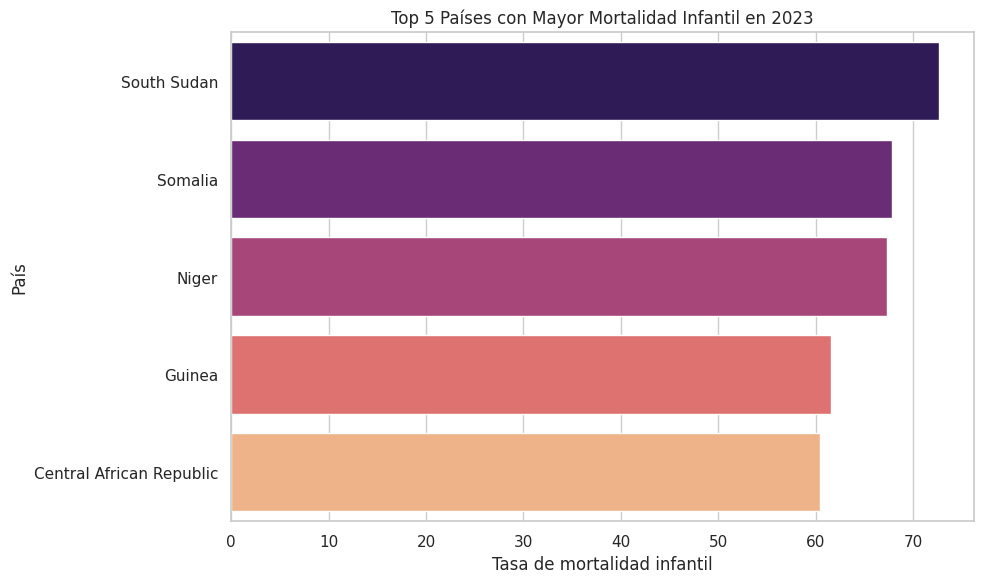

,area_name,year,value
537013,South Sudan,2023,72.616073
530991,Somalia,2023,67.839535
421048,Niger,2023,67.361474
219063,Guinea,2023,61.548732
95412,Central African Republic,2023,60.413259


,DATAFLOW,area,indicator,sex,wealth_quintile,year,value,data_source,country_notes,unit_measure,...,upper_bound,obs_status,area_code,area_name,indicator_code,indicator_name,sex_code,sex_name,wealth_code,wealth_name
537013,UNICEF:CME(1.0): Child Mortality,SSD: South Sudan,CME_MRY0: Infant mortality rate,_T: Total,_T: Total,2023,72.616073,UN_IGME,NaN,"D_PER_1000_B: Deaths per 1,000 live births",...,187.459398,A: Normal value,SSD,South Sudan,CME_MRY0,Infant mortality rate,_T,Total,_T,Total
530991,UNICEF:CME(1.0): Child Mortality,SOM: Somalia,CME_MRY0: Infant mortality rate,_T: Total,_T: Total,2023,67.839535,UN_IGME,NaN,"D_PER_1000_B: Deaths per 1,000 live births",...,147.350059,A: Normal value,SOM,Somalia,CME_MRY0,Infant mortality rate,_T,Total,_T,Total
421048,UNICEF:CME(1.0): Child Mortality,NER: Niger,CME_MRY0: Infant mortality rate,_T: Total,_T: Total,2023,67.361474,UN_IGME,NaN,"D_PER_1000_B: Deaths per 1,000 live births",...,86.853509,A: Normal value,NER,Niger,CME_MRY0,Infant mortality rate,_T,Total,_T,Total
219063,UNICEF:CME(1.0): Child Mortality,GIN: Guinea,CME_MRY0: Infant mortality rate,_T: Total,_T: Total,2023,61.548732,UN_IGME,NaN,"D_PER_1000_B: Deaths per 1,000 live births",...,80.444377,A: Normal value,GIN,Guinea,CME_MRY0,Infant mortality rate,_T,Total,_T,Total
95412,UNICEF:CME(1.0): Child Mortality,CAF: Central African Republic,CME_MRY0: Infant mortality rate,_T: Total,_T: Total,2023,60.413259,UN_IGME,NaN,"D_PER_1000_B: Deaths per 1,000 live births",...,80.914299,A: Normal value,CAF,Central African Republic,CME_MRY0,Infant mortality rate,_T,Total,_T,Total


In [53]:
def get_top_n_countries_mortality(year, n=10):

    top_countries = infant_total[
        (infant_total['year'] == year) &
        (~infant_total['area_code'].str.startswith('WB_', na=False)) &
        (infant_total['area_code'] != 'WORLD')
    ].sort_values('value', ascending=False).head(n)

    if not top_countries.empty:
        plt.figure(figsize=(10, 6))
        sns.barplot(data=top_countries, x='value', y='area_name', palette='magma')
        plt.title(f"Top {n} Países con Mayor Mortalidad Infantil en {year}")
        plt.xlabel("Tasa de mortalidad infantil")
        plt.ylabel("País")
        plt.tight_layout()
        plt.show()
        display(top_countries[['area_name', 'year', 'value']])
        return top_countries
    else:
        print(f"No se encontraron datos para el año {year}.")
        return pd.DataFrame()

print("Ejemplo de uso de get_top_n_countries_mortality:")
get_top_n_countries_mortality(2023, 5)

### 4. `get_mortality_by_wealth_quintile`

Esta función filtra la mortalidad infantil según un quintil de riqueza específico para un país y año determinados. Permite investigar cómo la mortalidad infantil varía entre diferentes grupos socioeconómicos.

In [43]:
def get_mortality_by_wealth_quintile(country_name, year, wealth_quintile_name):

    data = infant_df[
        (infant_df['area_name'] == country_name) &
        (infant_df['year'] == year) &
        (infant_df['wealth_name'] == wealth_quintile_name) &
        (infant_df['sex_code'] == '_T') # Total sex to avoid multiple entries
    ]
    if not data.empty:
        display(data[['area_name', 'year', 'wealth_name', 'value', 'lower_bound', 'upper_bound']])
        return data.iloc[0]
    else:
        print(f"No se encontraron datos para {country_name} en {year} para el quintil {wealth_quintile_name}.")
        return None

print("Ejemplo de uso de get_mortality_by_wealth_quintile (para India, 2020, Poorest):")
get_mortality_by_wealth_quintile("India", 2020, "Poorest")

Ejemplo de uso de get_mortality_by_wealth_quintile (para India, 2020, Poorest):
No se encontraron datos para India en 2020 para el quintil Poorest.


### 5. `Comparar mayor indice con menor por año (compare_highest_lowest_mortality_by_year)`

Esta función identifica y compara el país con la tasa de mortalidad infantil más alta y el país con la tasa más baja en un año determinado. Esto es útil para entender los extremos del indicador y las disparidades globales.

Ejemplo de uso de compare_highest_lowest_mortality_by_year (para el año 2023):


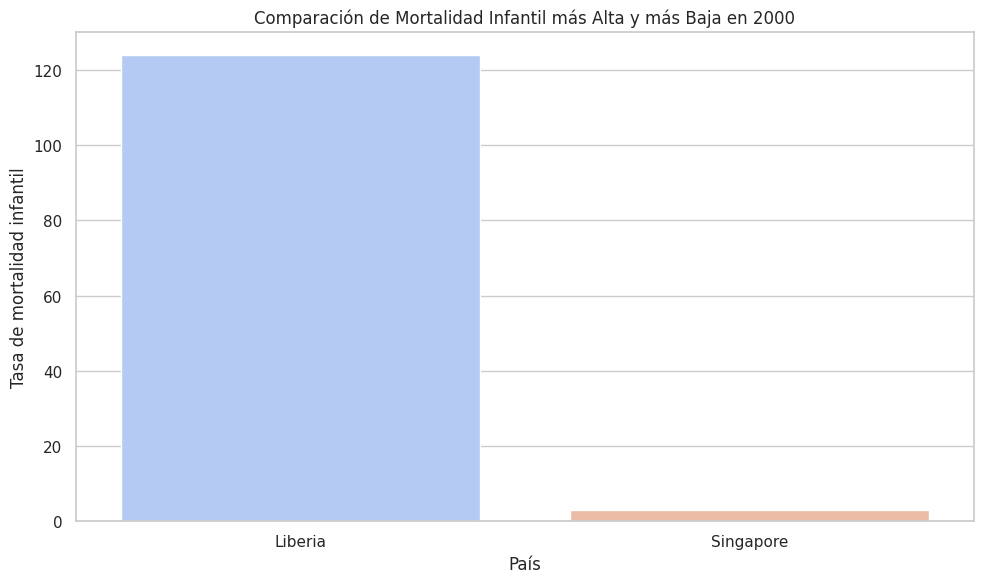


Detalles de la comparación:


,Category,Country,Value
0,Highest Mortality,Liberia,123.933967
1,Lowest Mortality,Singapore,3.015488


In [52]:
def compare_highest_lowest_mortality_by_year(year):
    year_data = infant_total[
        (infant_total['year'] == year) &
        (~infant_total['area_code'].str.startswith('WB_', na=False)) &
        (infant_total['area_code'] != 'WORLD')
    ]

    if year_data.empty:
        print(f"No se encontraron datos para el año {year}.")
        return

    highest_mortality_country = year_data.loc[year_data['value'].idxmax()]
    lowest_mortality_country = year_data.loc[year_data['value'].idxmin()]

    comparison_data = pd.DataFrame({
        'Category': ['Highest Mortality', 'Lowest Mortality'],
        'Country': [highest_mortality_country['area_name'], lowest_mortality_country['area_name']],
        'Value': [highest_mortality_country['value'], lowest_mortality_country['value']]
    })

    plt.figure(figsize=(10, 6))
    sns.barplot(data=comparison_data, x='Country', y='Value', hue='Category', palette='coolwarm', legend=False)
    plt.title(f"Comparación de Mortalidad Infantil más Alta y más Baja en {year}")
    plt.xlabel("País")
    plt.ylabel("Tasa de mortalidad infantil")
    plt.tight_layout()
    plt.show()

    print("\nDetalles de la comparación:")
    display(comparison_data)

print("Ejemplo de uso de compare_highest_lowest_mortality_by_year (para el año 2023):")
compare_highest_lowest_mortality_by_year(2000)